In [59]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import itertools

## Outline
Cleaning up metadata and merging into a single sheet

In [3]:
# read in sample metdata
md = pd.read_csv('/data/mhoffert/fiererlab/beer/data/Beer experiment - sample metadata - Sheet1 (1).tsv', sep='\t')

### Formatting alcolizer data

In [4]:
ap_data_week1 = pd.read_excel('/data/mhoffert/fiererlab/beer/data/Wild Ferm Project AP Data.xls',
                             skiprows=2)


In [5]:
ap_week1_clean = ap_data_week1.drop(labels=[0], axis=0).iloc[:, 3:].dropna(axis=0)

In [6]:
ap_data_week3 = pd.read_excel('/data/mhoffert/fiererlab/beer/data/Wild Ferm Proejct AP Data 2.xls',
                             skiprows=2)


In [7]:
ap_week3_clean = ap_data_week3.drop(labels=[0], axis=0).iloc[:, 3:].dropna(axis=0)


In [8]:
ap_week3_clean['Sample Name'] = ap_week3_clean['Sample Name'].apply(lambda x: f'{x}-3')

In [16]:
# make merged version
ap_data_clean = pd.concat([ap_week1_clean, ap_week3_clean]).rename(columns={'Sample Name':'Sample ID'})

### Data frame for plotting

In [9]:
plotdf = md[md['Filter replicate'].eq(1)].copy(deep=True)
plotdf['Hops'] = plotdf['Sample ID'].apply(lambda x: x[0])
plotdf['Location'] = plotdf['Sample ID'].apply(lambda x: x[1])
plotdf['treatment'] = plotdf['Sample ID'].apply(lambda x: x[:2])

### Sugar data

In [19]:
sugar_data = pd.read_excel('/data/mhoffert/fiererlab/beer/data/CSU Sugars.xlsx')

In [27]:
sugar_data['Sample ID'] = sugar_data['Sample Info'].apply(lambda x: x.replace(' Week ', '-'))
print(sugar_data.shape, plotdf.shape)
plotdf = pd.merge(plotdf, sugar_data.drop(labels=['ID #', 'Sample Info'], axis=1), 
         left_on='Sample ID', right_on='Sample ID', how='left')

(51, 8) (50, 12)


### Finalized merged data

In [28]:
merged_metadata = pd.merge(plotdf, ap_data_clean, left_on='Sample ID', right_on='Sample ID', how='outer')

In [29]:
merged_metadata['Filter replicate'] = merged_metadata['Filter replicate'].astype(str)

In [30]:
merged_metadata = pd.concat([pd.DataFrame(merged_metadata.iloc[1, :].apply(lambda x: x.replace('1','2') if type(x)==str else x)).T,
                             merged_metadata], axis=0)

In [33]:
merged_metadata.iloc[:5, 12:17]

,Fructose,Glucose,Sucrose,Maltose,Maltotriose
1,1.5,5.0,6.5,49.7,17.2
0,1.5,5.0,6.5,49.7,17.2
1,1.5,5.0,6.5,49.7,17.2
2,0.395265,0.083022,0.021214,4.092946,12.052336
3,0.326094,0.072644,0.021214,3.433126,9.639875


In [34]:
merged_metadata.sort_values('Sample ID').to_csv('/data/mhoffert/fiererlab/beer/project_data_and_tutorials/data/2022_10_12_WildBeer_metadata.tsv', sep='\t')

In [10]:
plotdf.shape

(50, 12)

## Plotting 

In [4]:
md = pd.read_csv('/data/mhoffert/fiererlab/beer/project_data_and_tutorials/data/2022_10_12_WildBeer_metadata.tsv', sep='\t')
plotdf = md.copy(deep=True)

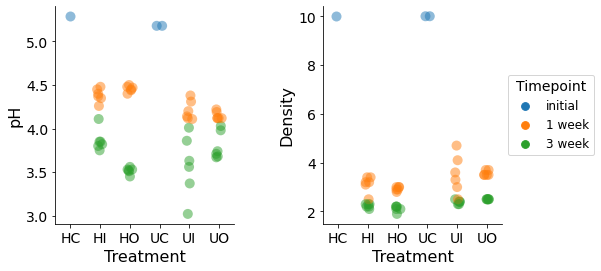

In [7]:
# sns.pointplot(data=plotdf, x='treatment', y='pH', hue='Hops', color='gray')
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 2, 1)
sns.stripplot(data=plotdf, x='treatment', y='pH', hue='timepoint', s=10, alpha=0.5)
sns.despine()
plt.tick_params(labelsize=14)
ax.set_ylabel('pH', fontsize=16)
ax.set_xlabel('Treatment', fontsize=16)
ax.get_legend().remove()
# lgd = ax.legend(fontsize=12, title='Timepoint', title_fontsize=14)

ax = fig.add_subplot(1, 2, 2)
sns.stripplot(data=plotdf, x='treatment', y='Density', hue='timepoint', s=10, alpha=0.5)
sns.despine()
plt.tick_params(labelsize=14)
ax.set_ylabel('Density', fontsize=16)
ax.set_xlabel('Treatment', fontsize=16)
lgd = ax.legend(fontsize=12, title='Timepoint', title_fontsize=14, loc='center left', bbox_to_anchor=(1, 0.5))
fig.subplots_adjust(wspace=0.5)

In [46]:
plotdf['Alcohol (% v/v)'] = plotdf['Alcohol (% v/v)'].replace('---', np.nan)
tidy_plotdf = plotdf.set_index('Sample ID')[['pH', 'Density', 'Glucose', 'Sucrose', 'Maltose', 'Maltotriose', 'Alcohol (% v/v)']].stack().reset_index().rename(columns={'level_1':'measurement', 0:'value'})
tidy_plotdf['timepoint (weeks)'] = tidy_plotdf['Sample ID'].apply(lambda x: '0' if 'C' in x else x.split('-')[-1])
tidy_plotdf['hops'] = tidy_plotdf['Sample ID'].apply(lambda x: x[0])
tidy_plotdf['exposure'] = tidy_plotdf['Sample ID'].apply(lambda x: x[1] if not 'C' in x else 'C')
tidy_plotdf['value'] = tidy_plotdf['value'].astype(float)

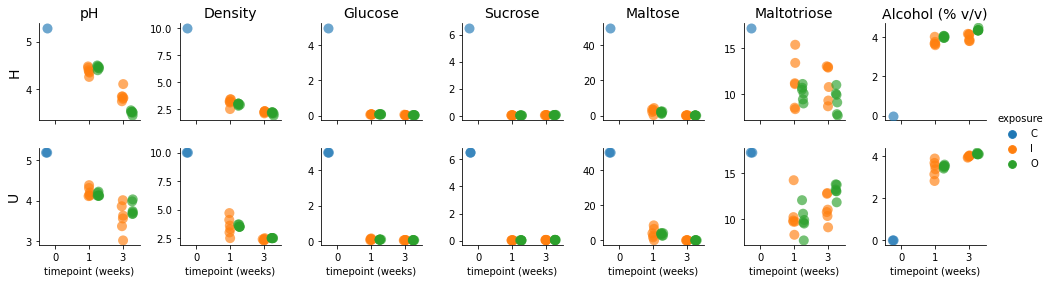

In [63]:
g = sns.catplot(data=tidy_plotdf, kind='strip', 
            col='measurement',
            x='timepoint (weeks)', 
            y='value', 
            sharey=False, 
            row='hops', 
            aspect=1, 
            height=2, 
            hue='exposure',
           dodge=True, s=10, alpha=0.65)

row_labels = ['H', 'U']
for row, col in itertools.product([0, 1], list(range(7))):
    title = g.axes[row, col].get_title()
    if row == 0:
        g.axes[row, col].set_title(title.split(' = ')[-1], fontsize=14)
    else:
        g.axes[row, col].set_title(' ')
    if col == 0:
        g.axes[row, col].set_ylabel(title.split(' = ')[1][0], fontsize=14)
        
    
    


In [55]:
for key, item in g.axes_dict.items():
    print(key, item)

('H', 'pH') AxesSubplot(0.0158069,0.578646;0.125566x0.335243)
('H', 'Density') AxesSubplot(0.154334,0.578646;0.125566x0.335243)
('H', 'Glucose') AxesSubplot(0.292861,0.578646;0.125566x0.335243)
('H', 'Sucrose') AxesSubplot(0.431389,0.578646;0.125566x0.335243)
('H', 'Maltose') AxesSubplot(0.569916,0.578646;0.125566x0.335243)
('H', 'Maltotriose') AxesSubplot(0.708443,0.578646;0.125566x0.335243)
('H', 'Alcohol (% v/v)') AxesSubplot(0.84697,0.578646;0.125566x0.335243)
('U', 'pH') AxesSubplot(0.0158069,0.145139;0.125566x0.335243)
('U', 'Density') AxesSubplot(0.154334,0.145139;0.125566x0.335243)
('U', 'Glucose') AxesSubplot(0.292861,0.145139;0.125566x0.335243)
('U', 'Sucrose') AxesSubplot(0.431389,0.145139;0.125566x0.335243)
('U', 'Maltose') AxesSubplot(0.569916,0.145139;0.125566x0.335243)
('U', 'Maltotriose') AxesSubplot(0.708443,0.145139;0.125566x0.335243)
('U', 'Alcohol (% v/v)') AxesSubplot(0.84697,0.145139;0.125566x0.335243)


<AxesSubplot:xlabel='timepoint', ylabel='pH'>

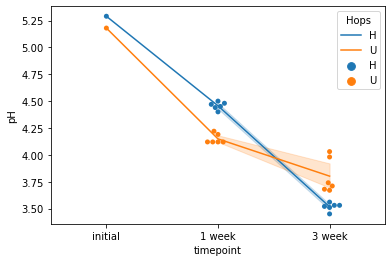

In [34]:
sns.lineplot(data=plotdf[plotdf['Location'].isin(['O', 'C'])], x='timepoint', y='pH', hue='Hops')
sns.swarmplot(data=plotdf[plotdf['Location'].isin(['O', 'C'])], x='timepoint', y='pH', hue='Hops')

<AxesSubplot:xlabel='timepoint', ylabel='pH'>

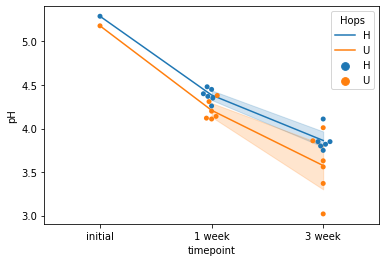

In [35]:
sns.lineplot(data=plotdf[plotdf['Location'].isin(['I', 'C'])], x='timepoint', y='pH', hue='Hops')
sns.swarmplot(data=plotdf[plotdf['Location'].isin(['I', 'C'])], x='timepoint', y='pH', hue='Hops')

In [25]:
sns.set_style(style='white')

In [24]:
# read an example PhyloFlash File
path = '/data/mhoffert/pipelines/cromwell-executions/quality_control/0d087274-8dc9-48f4-b74e-71b2a38b4ed3/call-PhyloFlash/shard-0/execution/'
df = pd.read_csv(f'{path}22419Fie_CommStd_S36_L001.phyloFlash.extractedSSUclassifications.csv')

In [30]:
df['species'] = df['taxonomy'].apply(lambda x: ' '.join(x.split(';')[-1].split(' ')[:2]))

In [32]:
df['read_cov_norm'] = df['read_cov'].divide(df['read_cov'].sum())

<AxesSubplot:>

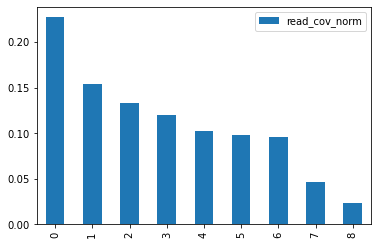

In [35]:
df.plot(kind='bar', stacked=True, y='read_cov_norm')

[Text(0, 0, '')]

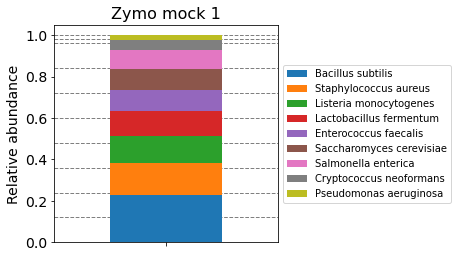

In [51]:
fig, ax = plt.subplots(figsize=(4,4))
df.set_index('species')[['read_cov_norm']].T.plot(kind='bar', stacked=True, ax=ax)
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
line = 0
for i in range(10):
    if i < 8:
        line += 0.12
    else:
        line += 0.02
    ax.axhline(line, color='gray', zorder=0, linewidth=1, linestyle='--')
plt.tick_params(labelsize=14)
ax.set_title('Zymo mock 1', fontsize=16)
ax.set_ylabel('Relative abundance', fontsize=14)
ax.set_xticklabels([''])

### SSU data

In [179]:
data = pd.read_csv('/data/mhoffert/fiererlab/beer/project_data_and_tutorials/data/2022_10_20_WildBeer.phyloFlash.extractedSSUclassifications.csv',
                   sep=',')

data['species'] = data['taxonomy'].apply(lambda x: x.split(';')[-1])

wide = data.groupby(
        ["species", "sample", ]
                   ).sum()['read_cov'].unstack().fillna(0).drop(labels=['CommStd', 'ExtB1', 'NTC', 'HC1', 'UC1', 'UC2', 'UI5-1', 'UI5-3'], axis=1)

otu_table = wide.divide(wide.sum())

In [180]:
md_cols = ['Sample ID', 'pH', 'Density', 'Glucose', 'Sucrose', 'Maltose', 'Maltotriose', 'Alcohol (% v/v)', 'timepoint', 'Hops', 'Location']
drop_taxa = ['Wickerhamomyces anomalus NRRL Y-366', 'Pseudomonas sp. 02C 26']
plotdf = otu_table[otu_table.sum(axis=1) > 0].drop(drop_taxa).stack().rename('abun').reset_index().merge(md[md_cols],  left_on='sample', right_on='Sample ID')
plotdf['taxa_group'] = plotdf['species'].apply(classify_species)
plotdf['treatment'] = plotdf.apply(lambda row: f"{row.loc['Hops'][0]}, {row.loc['Location'][0]}", axis=1)

In [181]:
taxa_group_plotdf = plotdf.groupby(['sample', 'taxa_group']).agg({'abun':sum, 'timepoint':'first', 'treatment':'first'}).reset_index()
taxa_group_plotdf

,sample,taxa_group,abun,timepoint,treatment
0,HI1-1,Enterobacteria,0.313246,1 week,"H, I"
1,HI1-1,Gluconobacter,0.000000,1 week,"H, I"
2,HI1-1,Lactobacilli,0.000000,1 week,"H, I"
3,HI1-1,Saccharomyces,0.686754,1 week,"H, I"
4,HI1-3,Enterobacteria,0.236225,3 week,"H, I"
...,...,...,...,...,...
175,UO6-1,Saccharomyces,1.000000,1 week,"U, O"
176,UO6-3,Enterobacteria,0.163357,3 week,"U, O"
177,UO6-3,Gluconobacter,0.000000,3 week,"U, O"
178,UO6-3,Lactobacilli,0.223119,3 week,"U, O"


In [182]:
sns.set(font_scale=1.1)
sns.set_style('white')

In [183]:
def classify_species(s):
    if any(i in s for i in ['Entero', 'Lelliottia', 'Pseudescherichia']):
        return 'Enterobacteria'
    elif 'Saccharo' in s:
        return "Saccharomyces"
    elif 'Lactobacillus' in s:
        return 'Lactobacilli'
    elif 'Glucono' in s:
        return 'Gluconobacter'
    else:
        return 'Other'
    
[(s, classify_species(s)) for s in plotdf['species'].unique()]

[('Enterobacter cloacae', 'Enterobacteria'),
 ('Enterobacter sp. 638', 'Enterobacteria'),
 ('Enterobacter sp. Iso-A4', 'Enterobacteria'),
 ('Gluconobacter oxydans', 'Gluconobacter'),
 ('Lactobacillus brevis ATCC 367', 'Lactobacilli'),
 ('Lactobacillus harbinensis', 'Lactobacilli'),
 ('Lactobacillus harbinensis DSM 16991', 'Lactobacilli'),
 ('Lactobacillus parabuchneri', 'Lactobacilli'),
 ('Lactobacillus paracasei', 'Lactobacilli'),
 ('Lelliottia amnigena', 'Enterobacteria'),
 ('Pseudescherichia vulneris', 'Enterobacteria'),
 ('Saccharomyces cerevisiae S288C', 'Saccharomyces')]

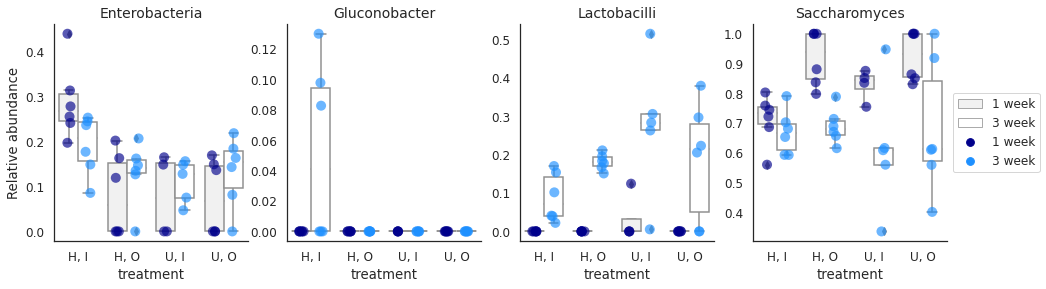

In [195]:
fig = plt.figure(figsize=(16, 4))
i = 1
hue_order = taxa_group_plotdf['treatment'].unique()
palette=['darkblue', 'dodgerblue', 'darkred', 'tomato']
for group in taxa_group_plotdf['taxa_group'].unique():
    subset = taxa_group_plotdf[taxa_group_plotdf.taxa_group.eq(group)]
    ax = fig.add_subplot(1, 4, i)
    sns.boxplot(data=subset, x='treatment', y='abun', hue='timepoint', color='white', zorder=0)
    sns.stripplot(data=subset, x='treatment', y='abun', hue='timepoint', zorder=1, alpha=0.65, dodge=True, palette=palette, s=10)
    if i < 4:
        ax.get_legend().remove()
        
    else:
        lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
    if i == 1:
        ax.set_ylabel('Relative abundance')
    else:
        ax.set_ylabel(' ')
        
    ax.set_title(group, fontsize=14)
    sns.despine()
    i += 1

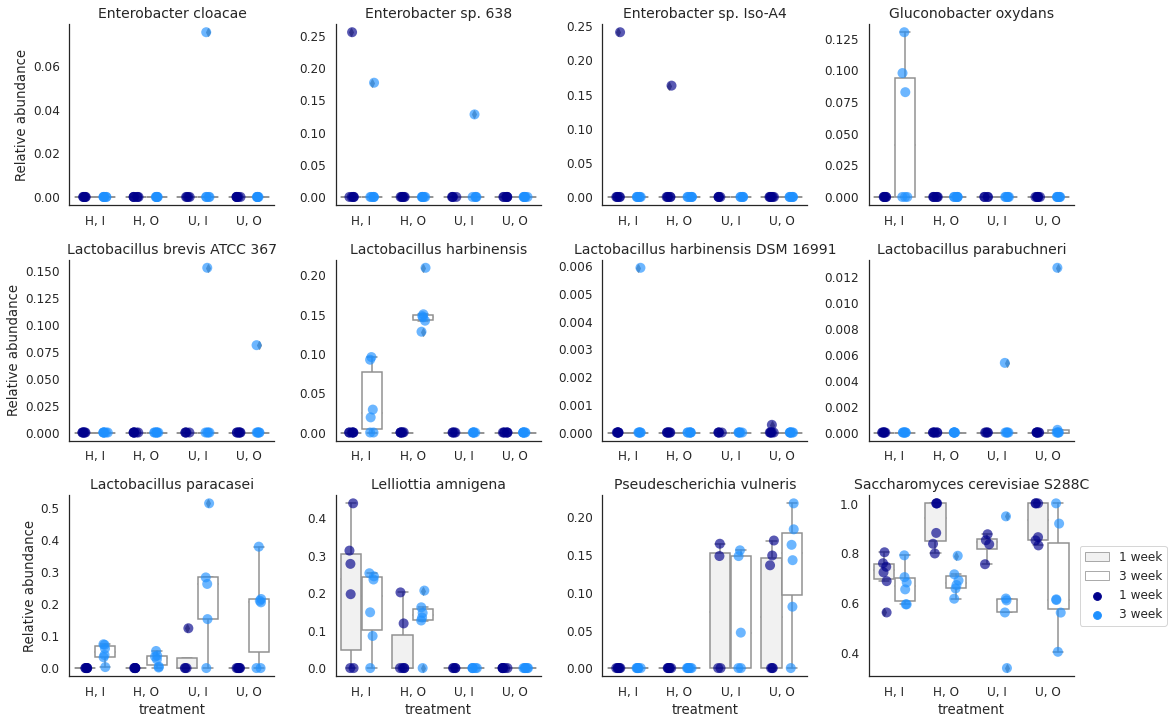

In [194]:
fig = plt.figure(figsize=(18, 12))
i = 1
hue_order = plotdf['treatment'].unique()
palette=['darkblue', 'dodgerblue', 'darkred', 'tomato']
for group in plotdf['species'].unique():
    subset = plotdf[plotdf.species.eq(group)]
    ax = fig.add_subplot(3, 4, i)
    sns.boxplot(data=subset, x='treatment', y='abun', hue='timepoint', color='white', zorder=0)
    sns.stripplot(data=subset, x='treatment', y='abun', hue='timepoint', zorder=1, alpha=0.65, dodge=True, palette=palette, s=10)
    
    if i < 12:
        ax.get_legend().remove()
    else:
        lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        
    if i < 9:
        ax.set_xlabel(' ')
    
    if i % 4 == 1:
        ax.set_ylabel('Relative abundance')
    else:
        ax.set_ylabel(' ')
        
    ax.set_title(group, fontsize=14)
    sns.despine()
    i += 1
    
fig.subplots_adjust(wspace=0.3, hspace=0.3)

In [191]:
len(plotdf['species'].unique())

12

In [224]:
plotdf['Alcohol (% v/v)'] = plotdf['Alcohol (% v/v)'].replace('---', np.nan).astype(float)

### Organisms vs metadata

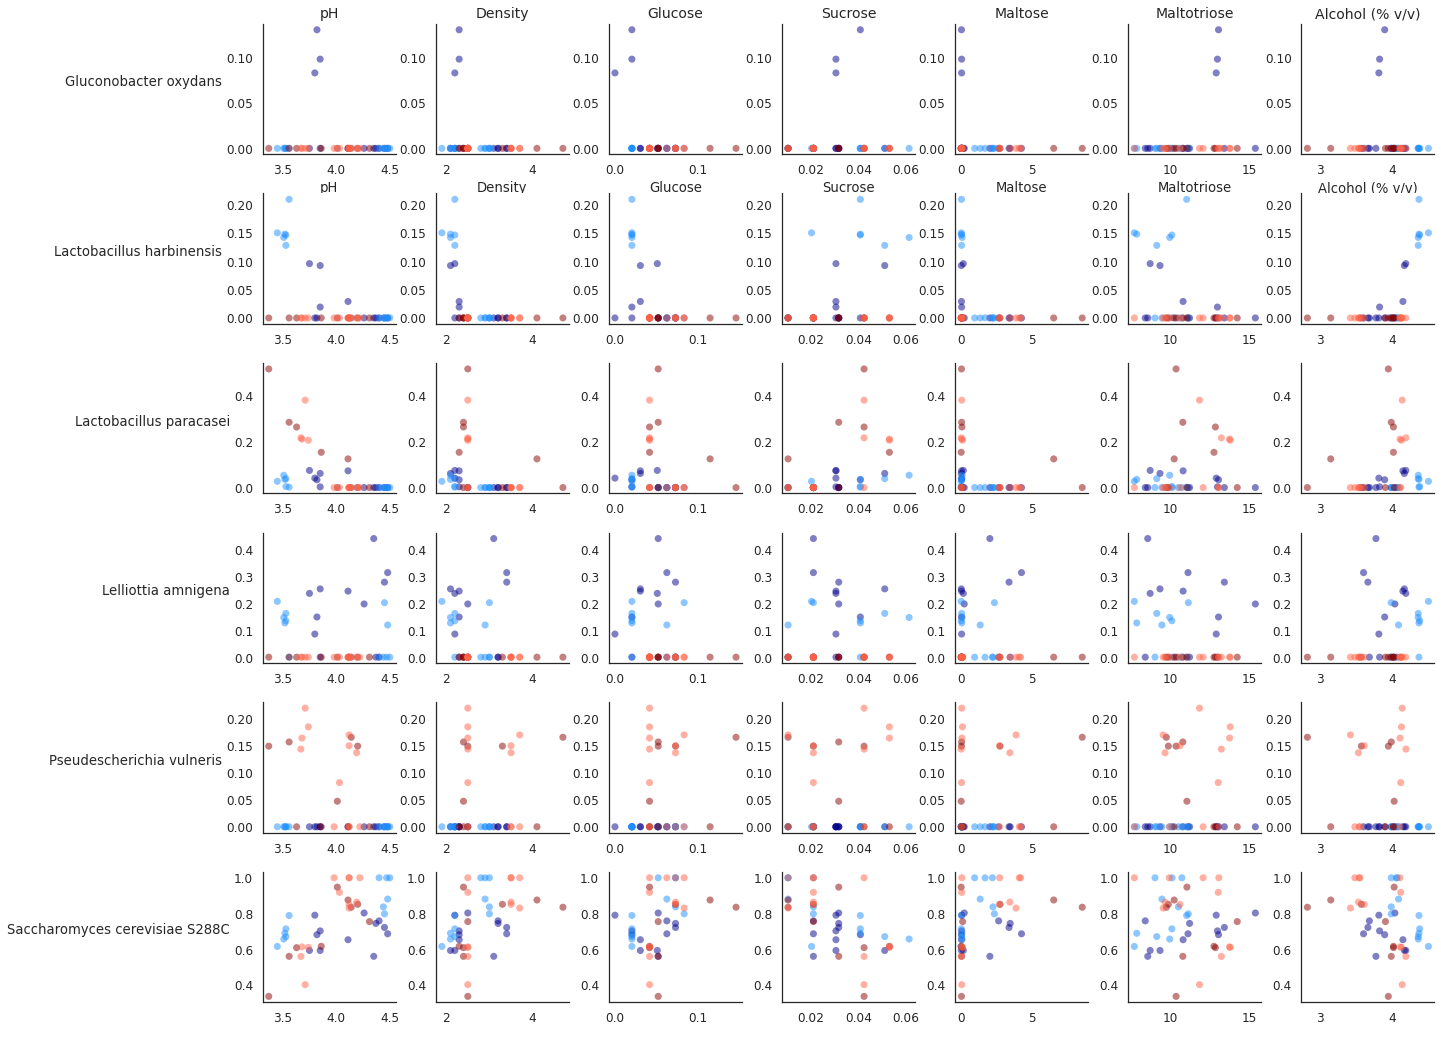

In [230]:
fig = plt.figure(figsize=(21, 18))
i, j = 1, 0
hue_order = plotdf['treatment'].unique()
palette=['darkblue', 'dodgerblue', 'darkred', 'tomato']
plot_species = ['Gluconobacter oxydans', 'Lactobacillus harbinensis',
                'Lactobacillus paracasei', 'Lelliottia amnigena', 
                'Pseudescherichia vulneris', 'Saccharomyces cerevisiae S288C']
metrics = ['pH', 'Density', 'Glucose', 'Sucrose', 'Maltose', 'Maltotriose', 'Alcohol (% v/v)']
for group in plot_species:
    for m in metrics:
        subset = plotdf[plotdf.species.eq(group)]
        ax = fig.add_subplot(6, 7, i)
        sns.scatterplot(data=subset, x=m, y='abun', s=50, alpha=0.5, linewidth=0, hue='treatment', palette=palette)        

        ax.get_legend().remove()
    #     if i < 12:
    #         ax.get_legend().remove()
    #     else:
    #         lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    #     if i < 9:
    #         ax.set_xlabel(' ')

    #     if i % 4 == 1:
    #         ax.set_ylabel('Relative abundance')
    #     else:
    #         ax.set_ylabel(' ')
        ax.set_xlabel(' ')
        if i < 8:    
            ax.set_title(m, fontsize=14)
        else:
            ax.set_title(' ')
             
        if i % 7 == 1:
            ax.set_ylabel(group,  ha='right', rotation=0)
        else:
            ax.set_ylabel(' ')
        sns.despine()
        

        # if i == 7:
        #     j = 0
        # else:
        #     j += 1
        i += 1
    
fig.subplots_adjust(wspace=0.3, hspace=0.3)

In [217]:
plotdf['species'].unique()

array(['Enterobacter cloacae', 'Enterobacter sp. 638',
       'Enterobacter sp. Iso-A4', 'Gluconobacter oxydans',
       'Lactobacillus brevis ATCC 367', 'Lactobacillus harbinensis',
       'Lactobacillus harbinensis DSM 16991',
       'Lactobacillus parabuchneri', 'Lactobacillus paracasei',
       'Lelliottia amnigena', 'Pseudescherichia vulneris',
       'Saccharomyces cerevisiae S288C'], dtype=object)

## Yeast abundance

In [198]:
yeast = pd.read_csv('/data/mhoffert/fiererlab/beer/project_data_and_tutorials/data/1011yeast_pangenome_sample_presence.tsv', sep='\t', index_col=0)

In [253]:
genes_matrix = pd.read_csv('/data/mhoffert/genomes/yeast/genesMatrix_PresenceAbsence.tab.gz', sep='\t', index_col=0)

In [264]:
genes_matrix.columns = [s[1:].replace('.', '-') for s in genes_matrix.columns.values]

In [280]:
col_colors = pd.Series(index=yeast.loc[:, yeast.sum() < 47].columns, data=(hops_prev - unhopped_prev).values)

In [278]:
(hops_prev - unhopped_prev)

103-augustus_masked-1449-AAT_3     -0.001812
105-augustus_masked-1454-AAT_3     -0.179348
1073-augustus_masked-BBM_6-7244     0.153986
1102-augustus_masked-ANR_2-7082     0.740942
1105-augustus_masked-AEN_3-18383    0.043478
                                      ...   
7604-YPL257W                       -0.041667
772-augustus_masked-AHA_2-9651      0.583333
7821-Q0045_NumOfGenes_9             0.043478
7831-Q0160                         -0.132246
887-augustus_masked-CGL_4-10494     0.088768
Length: 198, dtype: float64

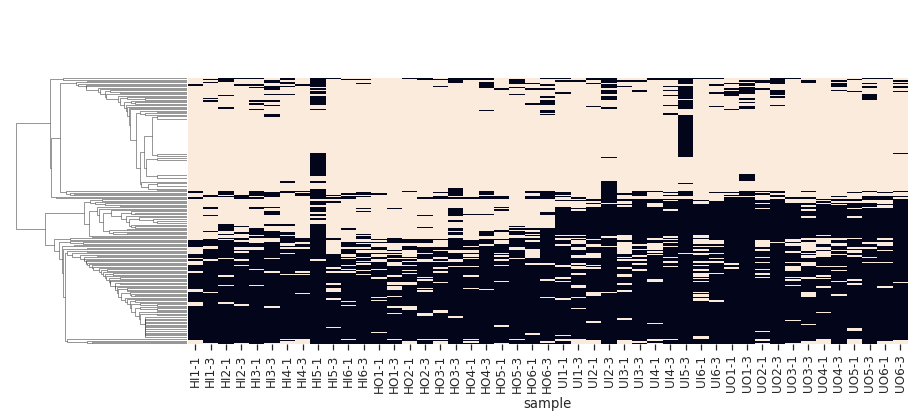

In [344]:
g = sns.clustermap(yeast.loc[:, yeast.sum() < 47].T, col_cluster=False, figsize=(16, 6))
g.ax_cbar.remove()
g.ax_heatmap.tick_params(right=False, bottom=True)
yticks = g.ax_heatmap.set_yticklabels([''] * 18)

In [233]:
subset = yeast.loc[:, yeast.sum() < 47]

In [240]:
hops_prev = subset[subset.index.str.contains('H')].sum(0) / len(subset[subset.index.str.contains('H')])
unhopped_prev = subset[subset.index.str.contains('U')].sum(0) / len(subset[subset.index.str.contains('U')])

In [306]:
top_different_genes = (hops_prev - unhopped_prev).sort_values().tail(20).index

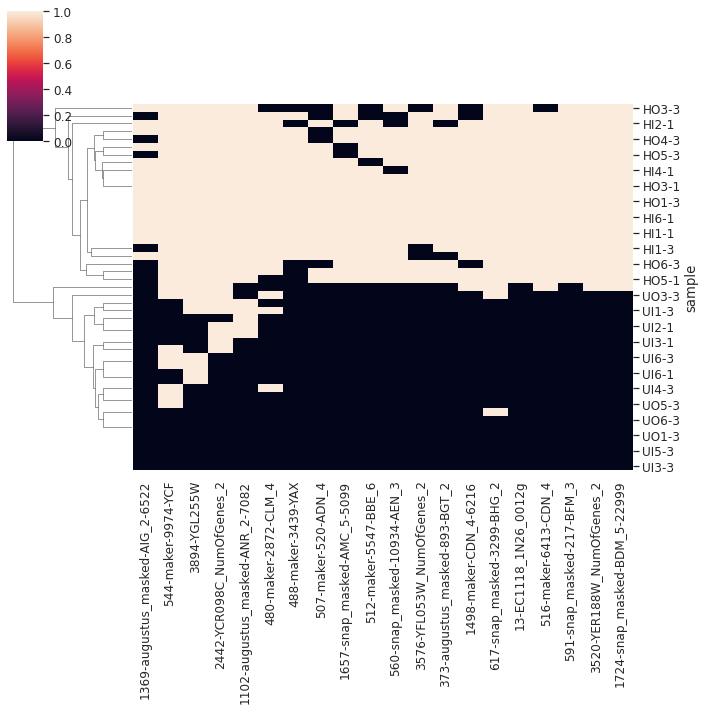

In [307]:
g = sns.clustermap(yeast.loc[:, top_different_genes], col_cluster=False)

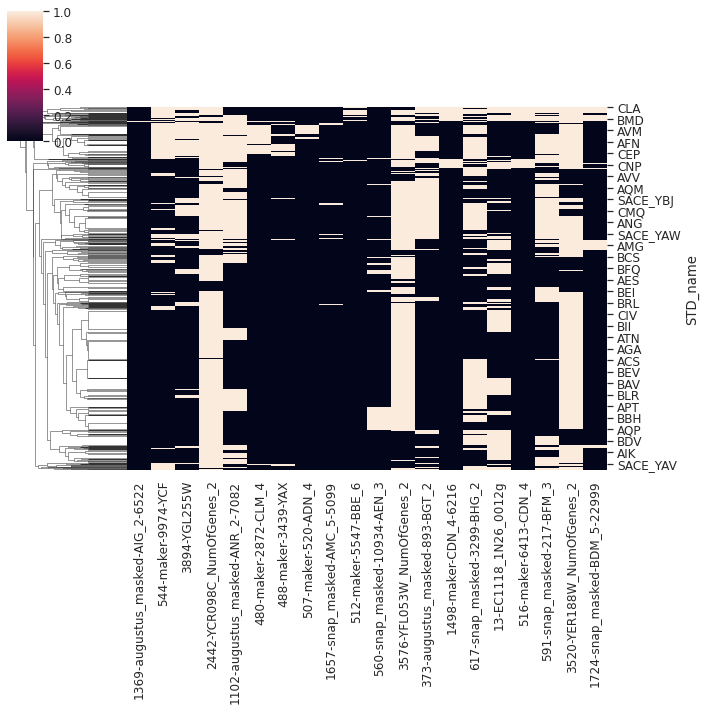

In [308]:
genomes = ['ARP', 'BDH', 'BMD', 'AMN', 'CFP']
sns.clustermap(genes_matrix.loc[:, top_different_genes], col_cluster=False)

In [319]:
top_genomes = genes_matrix.loc[:, top_different_genes].sum(1).sort_values()

In [322]:
top_genomes[top_genomes >= 10].index

Index(['ALA', 'SACE_YCJ', 'APA', 'AAD', 'CGN', 'AFM', 'CGG', 'ALH', 'BHS',
       'AKL', 'SACE_YCK', 'BHR', 'BHP', 'CGP', 'BHQ', 'SACE_YDK', 'CHG', 'BBC',
       'BFL', 'ABV', 'ASL', 'APM', 'BFA', 'CNC', 'AQI', 'BBF', 'CKK', 'AAP',
       'AKS', 'CEP', 'SACE_YBZ', 'BBD', 'CMH', 'AAN', 'SACE_YCW', 'AFN', 'CLA',
       'ARM', 'SACE_YAP', 'SACE_YCB', 'CLI', 'ATB', 'CMG', 'BDM', 'CMK', 'AMB',
       'AMC', 'CKS', 'AKR', 'ALC', 'ALK', 'CGQ', 'BRG', 'CGK', 'CHM', 'BEF',
       'ALB', 'CGI', 'CLN', 'AEF', 'BTS', 'ANT', 'CMN', 'ANR', 'BML', 'CHI',
       'ANV', 'BTE', 'CMI', 'ANS', 'AQN', 'ATR', 'AAL', 'CLM', 'BCV', 'CIC',
       'CMF', 'BDA', 'BDE', 'BDI', 'CDN', 'AFC', 'ALV', 'BDD', 'BDB', 'CBF',
       'BMM', 'ARP', 'BDH', 'BMD', 'AMN', 'CFP'],
      dtype='object', name='STD_name')

In [316]:
yeast_metadata = pd.read_excel('/data/mhoffert/genomes/yeast/41586_2018_30_MOESM3_ESM (3).xls', skiprows=3, sheet_name=0)

In [366]:
colors = pd.Series(dict(zip(temp2.value_counts().index, sns.color_palette('inferno_r', len(temp2.value_counts())))))

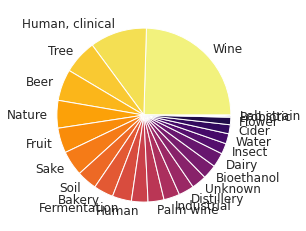

In [367]:
temp2 = yeast_metadata['Ecological origins']
piechart2 = plt.pie(temp2.value_counts() / len(temp2), labels=temp2.value_counts().index, colors=colors.values)

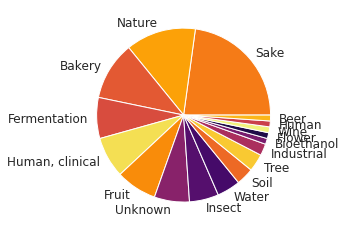

In [368]:
temp = yeast_metadata.set_index('Standardized name').loc[top_genomes[top_genomes >= 10].index, 'Ecological origins'] 
piechart = plt.pie(temp.value_counts() / len(temp), labels = temp.value_counts().index, colors=colors.reindex(temp.value_counts().index).values)

### Yeast gene functions

In [373]:
interpro_results = pd.read_csv('/data/mhoffert/genomes/yeast/allORFs_pangenome_filtered.interpro.tsv', sep='\t', header=None, index_col=0)

In [384]:
interpro_results.index.unique()

Index(['6650-YNL262W_NumOfGenes_2', '1744-snap_masked-CGD_5-5433',
       '4571-YIL091C', '2186-YBR199W', '4583-YIL102C-A', '7088-YOR124C',
       '6660-YNL273W', '6270-YMR203W', '2277-YBR287W',
       '1542-maker-BDM_5-23139',
       ...
       '5104-YKL034W', '3039-YDR347W', '2762-YDR073W',
       '1159-augustus_masked-ABP_6-5400', '4109-YGR207C',
       '1060-augustus_masked-ASN_8-20595', '4030-YGR131W', '1944-YBL071W-A',
       '4918-YJR005C-A', '4094-YGR193C'],
      dtype='object', name=0, length=6643)

In [388]:
pfam_interpro = interpro_results[interpro_results[3].eq('Pfam')]
pfam_interpro.loc[[gene for gene in top_different_genes  if gene in pfam_interpro.index], 12].unique()

array(['Sortilin, N-terminal', 'Zinc/iron permease',
       'Major facilitator,  sugar transporter-like',
       'Sortilin, C-terminal',
       'Hyphally-regulated cell wall protein, N-terminal', 'DhaK domain',
       'DhaL domain', 'Yeast membrane protein DUP/COS',
       'Hydantoinase/oxoprolinase, N-terminal',
       'Hydantoinase A/oxoprolinase', 'Hydantoinase B/oxoprolinase', '-'],
      dtype=object)

In [390]:
md

,Unnamed: 0,Sample Description,Sample Name,Sample ID,timepoint,Filter replicate,pH,Density,Scent notes,Notes,...,Alcohol (% v/v),Alcohol (% w/w),Specific Gravity,Ea (app. extract) (% w/w),Er (real extract) (% w/w),p (original extract) (% w/w),Concentration Sugar,RDF (real deg. of ferm.),ADF (% w/w),Calories (kcal/12oz)
0,0,Control Wort - Hopped Filter 1,HC1,HC1,initial,1,5.29,10.0,NaN,Independent pH were not taken for each filter ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20,"Hopped, Indoor, Jar 1, wk1, filter 1",HI1 wk 1 #1,HI1-1,1 week,1,4.48,3.4,"Grainy, 4VG",NaN,...,3.6,2.81,1.01297,3.32,4.64,10.15,3.32,55.59,67.29,135.03
2,44,"Hopped, Indoor, Jar 1, wk3, filter 1",HI1 wk 3 #1,HI1-3,3 week,1,3.75,2.2,"spicy, phenolic, 4VG, burnt rubber, soapy, aut...",NaN,...,4.18,3.28,1.00848,2.17,3.71,10.14,2.18,64.62,78.54,132.61
3,21,"Hopped, Indoor, Jar 2, wk1, filter 1",HI2 wk 1 #1,HI2-1,1 week,1,4.45,3.4,"Grainy, 4VG, IAA, ethyl butyrate",NaN,...,3.66,2.86,1.01248,3.2,4.54,10.14,3.2,56.53,68.46,134.59
4,45,"Hopped, Indoor, Jar 2, wk3, filter 1",HI2 wk 3 #1,HI2-3,3 week,1,4.11,2.3,"mild 4VG, Grainy, burnt rubber, autolysis",NaN,...,4.14,3.25,1.00871,2.23,3.75,10.11,2.24,64.13,77.92,132.43
5,22,"Hopped, Indoor, Jar 3, wk1, filter 1",HI3 wk 1 #1,HI3-1,1 week,1,4.37,3.2,"IAA, 4VG, strong merh sweetness (?)",NaN,...,---,---,0.00951,Out of range,---,---,Out of range,---,---,---
6,46,"Hopped, Indoor, Jar 3, wk3, filter 1",HI3 wk 3 #1,HI3-3,3 week,1,3.85,2.1,"phenolic, burnt rubber, grainy",NaN,...,4.16,3.26,1.00828,2.12,3.65,10.04,2.13,64.86,78.86,131.23
7,23,"Hopped, Indoor, Jar 4, wk1, filter 1",HI4 wk 1 #1,HI4-1,1 week,1,4.40,3.2,"Ethyl hex, 4VG, Grainy sweet",NaN,...,3.68,2.87,1.01214,3.11,4.46,10.09,3.11,57.09,69.16,133.77
8,47,"Hopped, Indoor, Jar 4, wk3, filter 1",HI4 wk 3 #1,HI4-3,3 week,1,3.82,2.3,"phenolic, 4VG, mild autolysis",NaN,...,3.89,3.05,1.00903,2.31,3.75,9.72,2.32,62.69,76.19,127.38
9,24,"Hopped, Indoor, Jar 5, wk1, filter 1",HI5 wk 1 #1,HI5-1,1 week,1,4.35,3.1,NaN,NaN,...,3.77,2.95,1.01149,2.95,4.33,10.11,2.95,58.47,70.87,133.74


In [391]:
top_different_genes

Index(['1369-augustus_masked-AIG_2-6522', '544-maker-9974-YCF', '3894-YGL255W',
       '2442-YCR098C_NumOfGenes_2', '1102-augustus_masked-ANR_2-7082',
       '480-maker-2872-CLM_4', '488-maker-3439-YAX', '507-maker-520-ADN_4',
       '1657-snap_masked-AMC_5-5099', '512-maker-5547-BBE_6',
       '560-snap_masked-10934-AEN_3', '3576-YFL053W_NumOfGenes_2',
       '373-augustus_masked-893-BGT_2', '1498-maker-CDN_4-6216',
       '617-snap_masked-3299-BHG_2', '13-EC1118_1N26_0012g',
       '516-maker-6413-CDN_4', '591-snap_masked-217-BFM_3',
       '3520-YER188W_NumOfGenes_2', '1724-snap_masked-BDM_5-22999'],
      dtype='object')